# Price Elasticity with PyMC

## Import packages

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import pymc as pm

/Users/kirawei/Library/Mobile Documents/com~apple~CloudDocs/data-science/price-elasticity-pymc/.venv/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [62]:
# impport datasets
data = pd.read_csv('data/synthetic_dataset.csv')
product_elasticities_df = pd.read_csv('data/product_elasticities_df.csv')

## EDA

### Price vs. elasticity

In [ ]:
rng = np.random.default_rng(seed=42)
### Price vs. Quantity - plot 6 products randomly selected from each state * brand combination
brand_choice = list(rng.choice(product_elasticities_df['product'].unique(),6, replace=False))
state_choice = product_elasticities_df['state'].unique()
product_list_choice = [i +' ('+ j + ')' for i in brand_choice for j in rng.choice(state_choice,1, replace=False)]

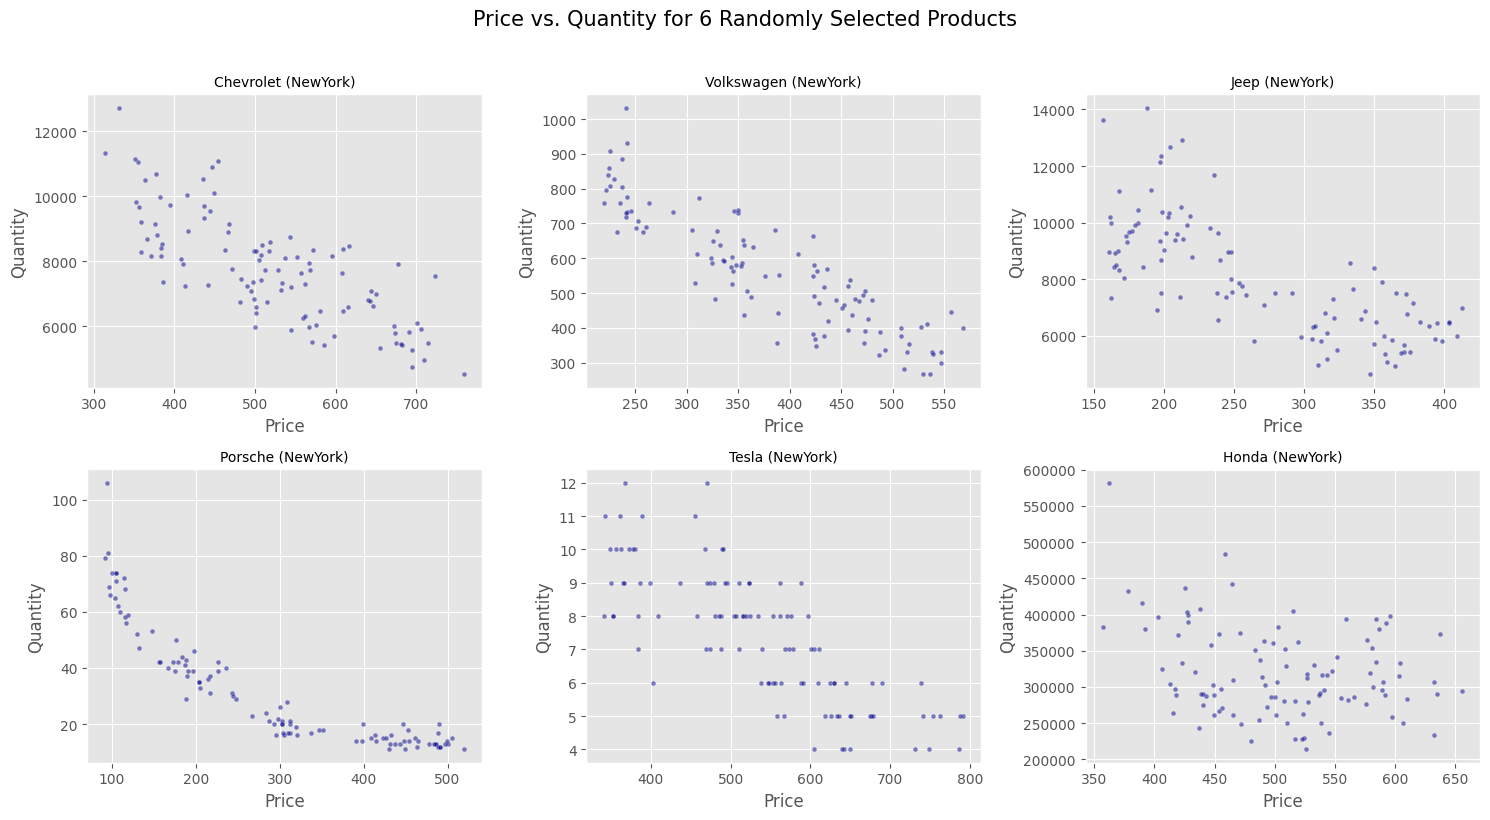

In [ ]:
# scatter plot

plt.style.use('ggplot')
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
for ax, product in zip(axes.flatten(), product_list_choice):
  sns.scatterplot(
  data = data.loc[data['product_id'] == product],
  x = 'price',
  y = 'quantity',
  ax = ax,
  alpha = 0.5,
  s=12,
  color = 'darkblue'
  )
  ax.set_xlabel('Price')
  ax.set_ylabel('Quantity')
  ax.set_title(product, fontsize=10)
plt.suptitle('Price vs. Quantity for 6 Randomly Selected Products', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('images/EDA/price_vs_quantity.png', bbox_inches='tight')

### Own elasticities vs. cross elasticities

In [126]:
# transform product elasticities dataframe to long format for plotting
product_elasticities_long_df = product_elasticities_df.melt(
  id_vars = ['category','state','product','elasticity','intercept'],
  var_name = 'paired_product',
  value_name = 'cross_elasticity'
)
# remove na
product_elasticities_long_df.dropna(axis=0, how='any', inplace=True)

# remove state from the paired product names
words_to_remove = [' (Florida)', ' (NewYork)']
for word in words_to_remove:
    product_elasticities_long_df['paired_product'] = product_elasticities_long_df['paired_product'].str.replace(word, '')
# save dataframe
product_elasticities_long_df.to_csv('data/product_elasticities_long_df.csv')

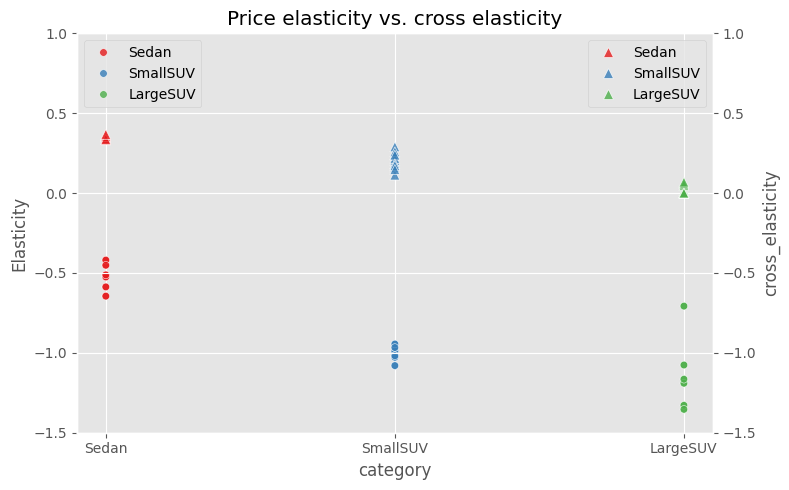

In [163]:
plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=product_elasticities_long_df,
    x='category',
    y='elasticity',
    hue='category',
    marker='o',
    palette='Set1',
    s=30,
    alpha=0.8,
    ax = ax
)
ax.set_ylim(-1.5, 1)
ax.set_ylabel('Elasticity')
ax.legend(loc='upper left')
ax2 = ax.twinx()
sns.scatterplot(
    data=product_elasticities_long_df,
    x='category',
    y='cross_elasticity',
    hue='category',
    marker='^',
    palette='Set1',
    s=50,
    alpha=0.8,
    ax = ax2
)
ax2.set_ylim(-1.5, 1)
ax2.legend(loc='upper right')
plt.title('Price elasticity vs. cross elasticity')
plt.tight_layout()
#plt.savefig('images/EDA/elasticity_crosselasticity.png')